In [1]:
# March 10, 2026
# import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
from jax import jit

import jax.random as jr
import jax.numpy as jnp
from datatypes import QP, IntegratorConfig
from target import gen_perturb_precision
from hamiltonian import gaussian_hamiltonian
from sampler import hmc_sampler, chmc_sampler, extract_positions, extract_energy
from metrics import compute_accept_rate

import time

import numpy as np

In [2]:
high_κ_vec = jnp.array([101, -9])
high_κ_vec[::-1]

Array([ -9, 101], dtype=int64)

In [3]:
# initial key
key = jax.random.PRNGKey(1)

# dimensions
dim = 2
Mass_inv = jnp.eye(dim)
high_κ_vec = jnp.array([101, -99])
κ100_mat = jnp.array([high_κ_vec, high_κ_vec[::-1]])
bias = jnp.linalg.det(κ100_mat)

target_mat = gen_perturb_precision(dim)
H = gaussian_hamiltonian(κ100_mat, mass_inv=Mass_inv)
H_flat = lambda qp_flat: H(QP.from_array(qp_flat))

# Set parameters
tau = 0.025
T = 1.0
N = int(jnp.floor(T / tau))
tol = 1e-2
max_iter = 2

config = IntegratorConfig(τ=tau,
                          T=T,
                          N=N,
                          tol=tol,
                          max_iter = max_iter)

# random draw keys
burnin_samples = 30
mainnum_samples = 1000
burninkey, mainkey1, mainkey2 = jr.split(key, 3)
keys_init = jr.split(burninkey, burnin_samples)
hmckeys_main = jr.split(mainkey1, mainnum_samples)
chmckeys_main = jr.split(mainkey2, mainnum_samples)

# initial qp-sample
qp_init = jr.normal(key, shape=(2 * dim,))
qp_init = QP.from_array(qp_init)
# initial kernel state
init_sample = [qp_init.to_array(), 1, False]

In [4]:
# ========================================
# HMC: Single Shot
# ========================================
# compile
start = time.time()
jhmc_sampler = jit(hmc_sampler, static_argnums=(2, 3))
sample_hmc = jhmc_sampler(init_sample, keys_init, H_flat, config)
jax.block_until_ready(sample_hmc)
end = time.time()
print(f"burn in run {burnin_samples} samples: {end - start: .3e}, \n single run {(end - start)/burnin_samples: .3e}")
# main run
start = time.time()
sample_hmc = jhmc_sampler(init_sample, hmckeys_main,  H_flat, config)
jax.block_until_ready(sample_hmc)
end = time.time()
print(
    f"Main run:\n {mainnum_samples} runs: {end - start: .3e} \n 1 run:  {(end-start)/mainnum_samples: .3e}"
)

burn in run 30 samples:  3.949e-01, 
 single run  1.316e-02
Main run:
 1000 runs:  2.929e-01 
 1 run:   2.929e-04


In [5]:
# ========================================
# CHMC: Single Shot
# ========================================
start = time.time()
jchmc_sampler = jit(chmc_sampler, static_argnums=(2,3,4))
sample_chmc = jchmc_sampler(init_sample, keys_init, H_flat, config)
jax.block_until_ready(sample_chmc)
end = time.time()
print(f"CHMC burn in run {burnin_samples} samples: {end - start: .3e}, \n single run {(end - start)/burnin_samples: .3e}")
start = time.time()
sample_chmc = jchmc_sampler(init_sample, hmckeys_main, H_flat, config)
jax.block_until_ready(sample_chmc)
end = time.time()
print(
    f"CHMC Main run:\n {mainnum_samples} runs: {end - start:.2f} \n     1 run:  {(end-start)/mainnum_samples: .3e}"
)

CHMC burn in run 30 samples:  5.599e-01, 
 single run  1.866e-02
CHMC Main run:
 1000 runs: 0.35 
     1 run:   3.454e-04


hmc_chain shape: (986, 2)
chmc_chain shape: (1000, 2)


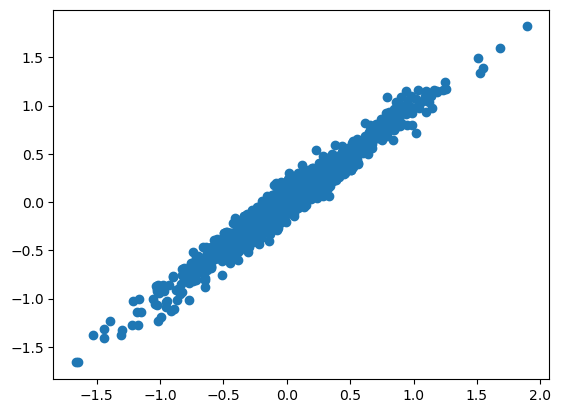

In [6]:
import matplotlib.pyplot as plt

hmc_chain = extract_positions(sample_hmc, accepted_only=True)
print(f'hmc_chain shape: {hmc_chain.shape}')
chmc_chain = extract_positions(sample_chmc, accepted_only=True)
print(f'chmc_chain shape: {chmc_chain.shape}')
# plt.hist2d(hmc_chain[:,0], hmc_chain[:,1], bins=50)
plt.scatter(hmc_chain[:,0], hmc_chain[:,1]) 

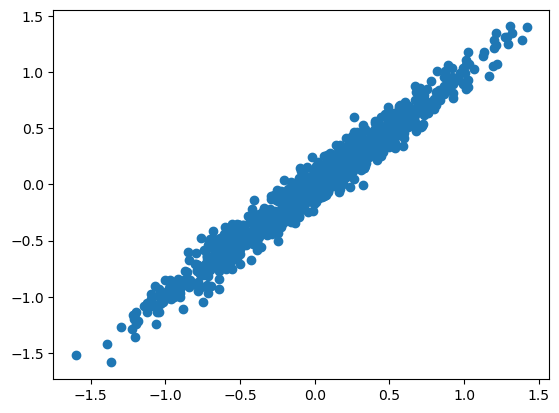

In [73]:
# plt.hist2d(chmc_chain[:,0], chmc_chain[:,1], bins=50)
plt.scatter(chmc_chain[:,0], chmc_chain[:,1]) 

In [202]:
testinv = jnp.linalg.inv(κ100_mat)

(1001, 1001, 2)
(1001, 1001, 2)


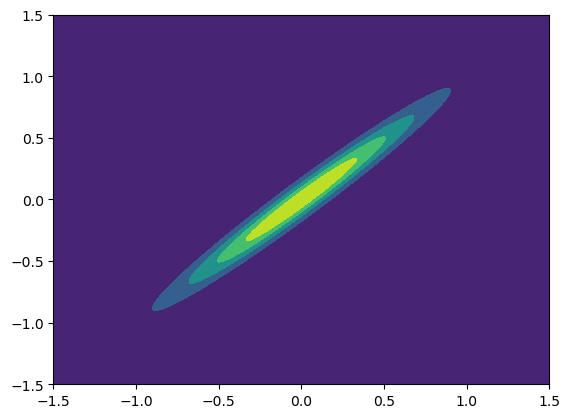

In [203]:
xvals = np.linspace(-1.5, 1.5, 1001)
yvals = np.linspace(-1.5, 1.5, 1001)
X, Y = jnp.meshgrid(xvals, yvals)
XY = jnp.stack([X, Y], axis=-1)
print(XY.shape)
AXY = XY @ κ100_mat.T
print(AXY.shape)
Z = jnp.einsum('...i,...i ->...', XY,AXY)
pdf = np.exp(-0.5 * Z)
levels = np.linspace(pdf.min(), pdf.max(), 6)

# plot
fig, ax = plt.subplots()

ax.contourf(X, Y, pdf, levels=levels)

plt.show()

(1001, 1001, 2)
(1001, 1001, 2)


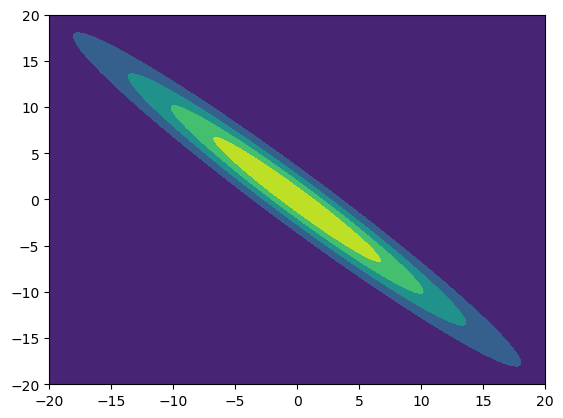

In [206]:
xvals = np.linspace(-20, 20, 1001)
yvals = np.linspace(-20, 20, 1001)
X, Y = jnp.meshgrid(xvals, yvals)
XY = jnp.stack([X, Y], axis=-1)
print(XY.shape)
AXY = XY @ testinv
print(AXY.shape)
Z = jnp.einsum('...i,...i ->...', XY,AXY)
pdf = np.exp(-0.5 * Z)
levels = np.linspace(pdf.min(), pdf.max(), 6)

# plot
fig, ax = plt.subplots()

ax.contourf(X, Y, pdf, levels=levels)

plt.show()

In [81]:
# ========================================
# CHMC v HMC: fixed κ, τ sweep
# ========================================
dim = 2
dims = [2]
c_step = 11
runs = 20
τcounts = np.array([40, 50, 64, 80, 100])
τs = 1/τcounts
numτs = len(τs)
perturb_val = jnp.arange(c_step)/((c_step-1)*2)
mcmc_min_exp = 2
mcmc_max_exp = 3
mcmc_iter_count = 7
lens = jnp.logspace(mcmc_min_exp, mcmc_max_exp, mcmc_iter_count, base=10, dtype=int)
hmc_chainring = []
chmc_chainring = []
# hmcΔH_ring = []
# chmcΔH_ring = []
# hmc_acceptrates = []
# chmc_acceptrates = []
chainringindex = []
true_matrices = []

totaltime = time.time()

jhmc_sampler = jit(hmc_sampler, static_argnums=(2,3))
jchmc_sampler = jit(chmc_sampler, static_argnums=(2,3,4))

Mass_inv = jnp.eye(dim)
key1, key2, key3 = jr.split(key, 3)
keyring = jr.split(key1, numτs)
chmckeyring = jr.split(key2, numτs*len(lens)*runs)
hmckeyring = jr.split(key3, numτs*len(lens)*runs)

high_κ_vec = jnp.array([101, -99])
κ100_mat = jnp.array([high_κ_vec, high_κ_vec[::-1]])
for k,val in enumerate(τs):
# only doing one dim right now 
    tau = 0.05
    T = 1.0
    N = int(jnp.ceil(T / tau))
    tol = 1e-2
    max_iter = 2
    config = IntegratorConfig(τ=val,
                            T=T,
                            N=N,
                            tol=tol,
                            max_iter = max_iter)
    pval = perturb_val[-3]
    target_mat = κ100_mat
    true_matrices.append(target_mat)
    H = gaussian_hamiltonian(target_mat, mass_inv=Mass_inv)
    H_flat = lambda qp_flat, H=H: H(QP.from_array(qp_flat))
    qp_init = jr.normal(keyring[k], shape=(2 * dim,))
    init_sample = [qp_init, 1, False]
    for j, mainnum_samples in enumerate(lens):
        for i in range(runs):
            hmc_keys_main = jr.split(hmckeyring[k+j+i], mainnum_samples)

            # HMC samples
            
            start = time.time()
            sample_hmc = jhmc_sampler(init_sample, hmc_keys_main, H_flat, config)
            jax.block_until_ready(sample_hmc)
            end = time.time()
            print(f"HMC Main run:\n ({dim}, {val: .2f}, {mainnum_samples}) runs: {end - start:.2f} \n 1 run:  {(end-start)/mainnum_samples: .3e}")
            hmc_chainring.append(extract_positions(sample_hmc, accepted_only=True))
            
            chmc_keys_main = jr.split(chmckeyring[k+j+i], mainnum_samples)
            # CHMC samples
            start = time.time()
            sample_chmc = jchmc_sampler(init_sample, chmc_keys_main, H_flat, config)
            jax.block_until_ready(sample_chmc)
            end = time.time()
            print(f"CHMC Main run:\n ({dim}, {val: .2f}, {mainnum_samples}) runs: {end - start:.2f} \n 1 run:  {(end-start)/mainnum_samples: .3e}")
            
            chmc_chainring.append(extract_positions(sample_chmc, accepted_only=True))
            # chmcΔH_ring.append(extract_energy(sample_chmc, accepted_only=True))
            # chmc_acceptrates.append(compute_accept_rate(sample_chmc))
            chainringindex.append((val,mainnum_samples))
print(f"HMC v CHMC Chain Gen Total Time: {time.time() - totaltime:.3f}")

HMC Main run:
 (2,  0.03, 100) runs: 0.32 
 1 run:   3.219e-03
CHMC Main run:
 (2,  0.03, 100) runs: 0.36 
 1 run:   3.572e-03
HMC Main run:
 (2,  0.03, 100) runs: 0.00 
 1 run:   5.870e-06
CHMC Main run:
 (2,  0.03, 100) runs: 0.00 
 1 run:   3.669e-05
HMC Main run:
 (2,  0.03, 100) runs: 0.00 
 1 run:   5.119e-06
CHMC Main run:
 (2,  0.03, 100) runs: 0.00 
 1 run:   3.521e-05
HMC Main run:
 (2,  0.03, 100) runs: 0.00 
 1 run:   4.952e-06
CHMC Main run:
 (2,  0.03, 100) runs: 0.00 
 1 run:   3.554e-05
HMC Main run:
 (2,  0.03, 100) runs: 0.00 
 1 run:   5.140e-06
CHMC Main run:
 (2,  0.03, 100) runs: 0.00 
 1 run:   3.600e-05
HMC Main run:
 (2,  0.03, 100) runs: 0.00 
 1 run:   5.240e-06
CHMC Main run:
 (2,  0.03, 100) runs: 0.00 
 1 run:   3.524e-05
HMC Main run:
 (2,  0.03, 100) runs: 0.00 
 1 run:   5.021e-06
CHMC Main run:
 (2,  0.03, 100) runs: 0.00 
 1 run:   3.518e-05
HMC Main run:
 (2,  0.03, 100) runs: 0.00 
 1 run:   5.009e-06
CHMC Main run:
 (2,  0.03, 100) runs: 0.00 
 1 r

In [112]:
print(chmc_chainring[0][0],(chmc_chainring[0]-chmc_chainring[0].mean(axis=0))[0], f'μ: {chmc_chainring[0].mean(axis=0)}')
chmc_chainring[0][0] - chmc_chainring[0].mean(axis=0)

[-0.08789293 -0.539094  ] [-0.40672266 -0.83147526] μ: [0.31882975 0.2923813 ]


Array([-0.40672266, -0.83147526], dtype=float32)

In [126]:
X = chmc_chainring[0] - chmc_chainring[0].mean(axis=0)
n = chmc_chainring[0].shape[0]
cov_test = (1/(n-1))*X.T@X
print(jnp.cov(X.T))
print(cov_test)
X[:,0].std()**2

[[0.20783557 0.21839528]
 [0.21839528 0.24386159]]
[[0.20783564 0.21839537]
 [0.21839537 0.24386154]]


Array(0.20575722, dtype=float32)

In [ ]:
# ========================================
# τChain Ring: Analysis
# (numτs, len, run )
# ========================================
import metrics
# CHMC
chmc_cov_matrices = []
cov_τmat_id = []
for i,chain in enumerate(chmc_chainring):
    chmc_cov_matrices.append(metrics.cov(chain))
    cov_τmat_id.append(i)
chmc_cov_matrices = jnp.array(chmc_cov_matrices).reshape(numτs,mcmc_iter_count,runs,dim,dim)

# HMC
hmc_cov_matrices = []
for chain in hmc_chainring:
    hmc_cov_matrices.append(metrics.cov(chain))
hmc_cov_matrices = jnp.array(hmc_cov_matrices).reshape(numτs,mcmc_iter_count,runs,dim,dim)

true_matrices = jnp.array(true_matrices)

In [ ]:
print(chmc_cov_matrices[3, 0, 0])
print()

Array([[0.5001717 , 0.31277588],
       [0.31277588, 0.54994315]], dtype=float32)

In [142]:
# ========================================
# τCHMC Chain Ring: Analysis
# Downstream analytics
# ring.shape: (numτs, len, run )
# ========================================
true_cov_matrices = jax.vmap(jnp.linalg.inv)(true_matrices)
vmaxtrdiff = jax.vmap(jax.vmap(jax.vmap(metrics.maxtracediff, in_axes=(0,None)),                                    #axis0= 5
                      in_axes=(0,None)), #axis (0,None) size 7
                      in_axes=(0,0)) #axis (0,0) size 20)
chmc_cov_metric = vmaxtrdiff(chmc_cov_matrices, true_cov_matrices)
hmc_cov_metric = vmaxtrdiff(hmc_cov_matrices, true_cov_matrices)

conds = jax.vmap(lambda x: jnp.linalg.cond(x, p=np.inf))(true_cov_matrices)


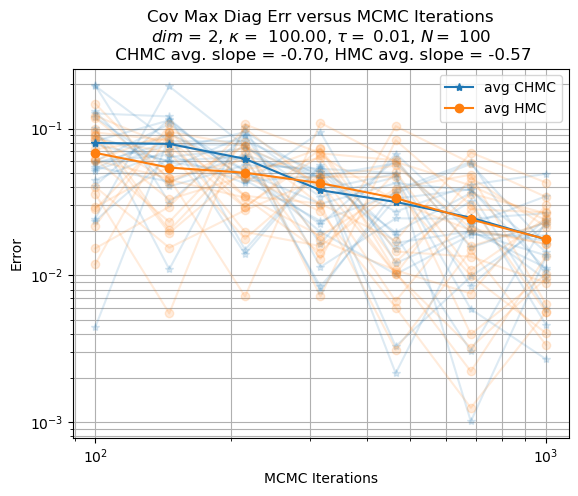

In [268]:
from matplotlib import pyplot as plt
# from plotting import gen_plots

def gen_τ_plots(lens, 
              chmc_metrics, 
              hmc_metrics, 
              config, 
              i, 
              dims = dims,
              cond = conds,
              slope=False, 
              avg=True,
              title = 'Cov Max Diag Err versus MCMC Iterations'
              ):
    plt.loglog(lens, chmc_metrics[i,:], '-*', color = 'C0', alpha = 0.15)
    plt.loglog(lens, hmc_metrics[i,:], '-o', color = 'C1', alpha = 0.15)
    title = title
    subtitle1 = f'\n$dim$ = {dims[0]}, $\kappa$ = {cond: 0.2f}, $\\tau = $ {config.τ}, $N = $ {config.N}'
    if avg:
        avg_chmc = np.mean(chmc_metrics[i,:], axis = 1)
        plt.loglog(lens, avg_chmc, '-*', color = 'C0', label ='avg CHMC', alpha = 1)
        avg_hmc = np.mean(hmc_metrics[i,:], axis = 1)
        plt.loglog(lens, avg_hmc , '-o', color = 'C1', label ='avg HMC', alpha = 1)
    if slope:
        chmc_p = np.polyfit(np.log(lens), np.log(avg_chmc), 1)
        hmc_p = np.polyfit(np.log(lens), np.log(avg_hmc), 1)

        # slop of avg chain subtitle
        subtitle2 = f'\n CHMC avg. slope = {chmc_p[0]:.2f}, HMC avg. slope = {hmc_p[0]:.2f}'

        # combined subtitle
        plt.title(title+subtitle1+subtitle2)
    else:
        plt.title(title + subtitle1)
    plt.xlabel('MCMC Iterations')
    plt.ylabel('Error')
    plt.grid(which='minor')
    plt.grid(which='major')
    plt.legend()
gen_τ_plots(lens, chmc_cov_metric, hmc_cov_metric, config, 0, dims=dims, cond = conds[-3], slope=True)

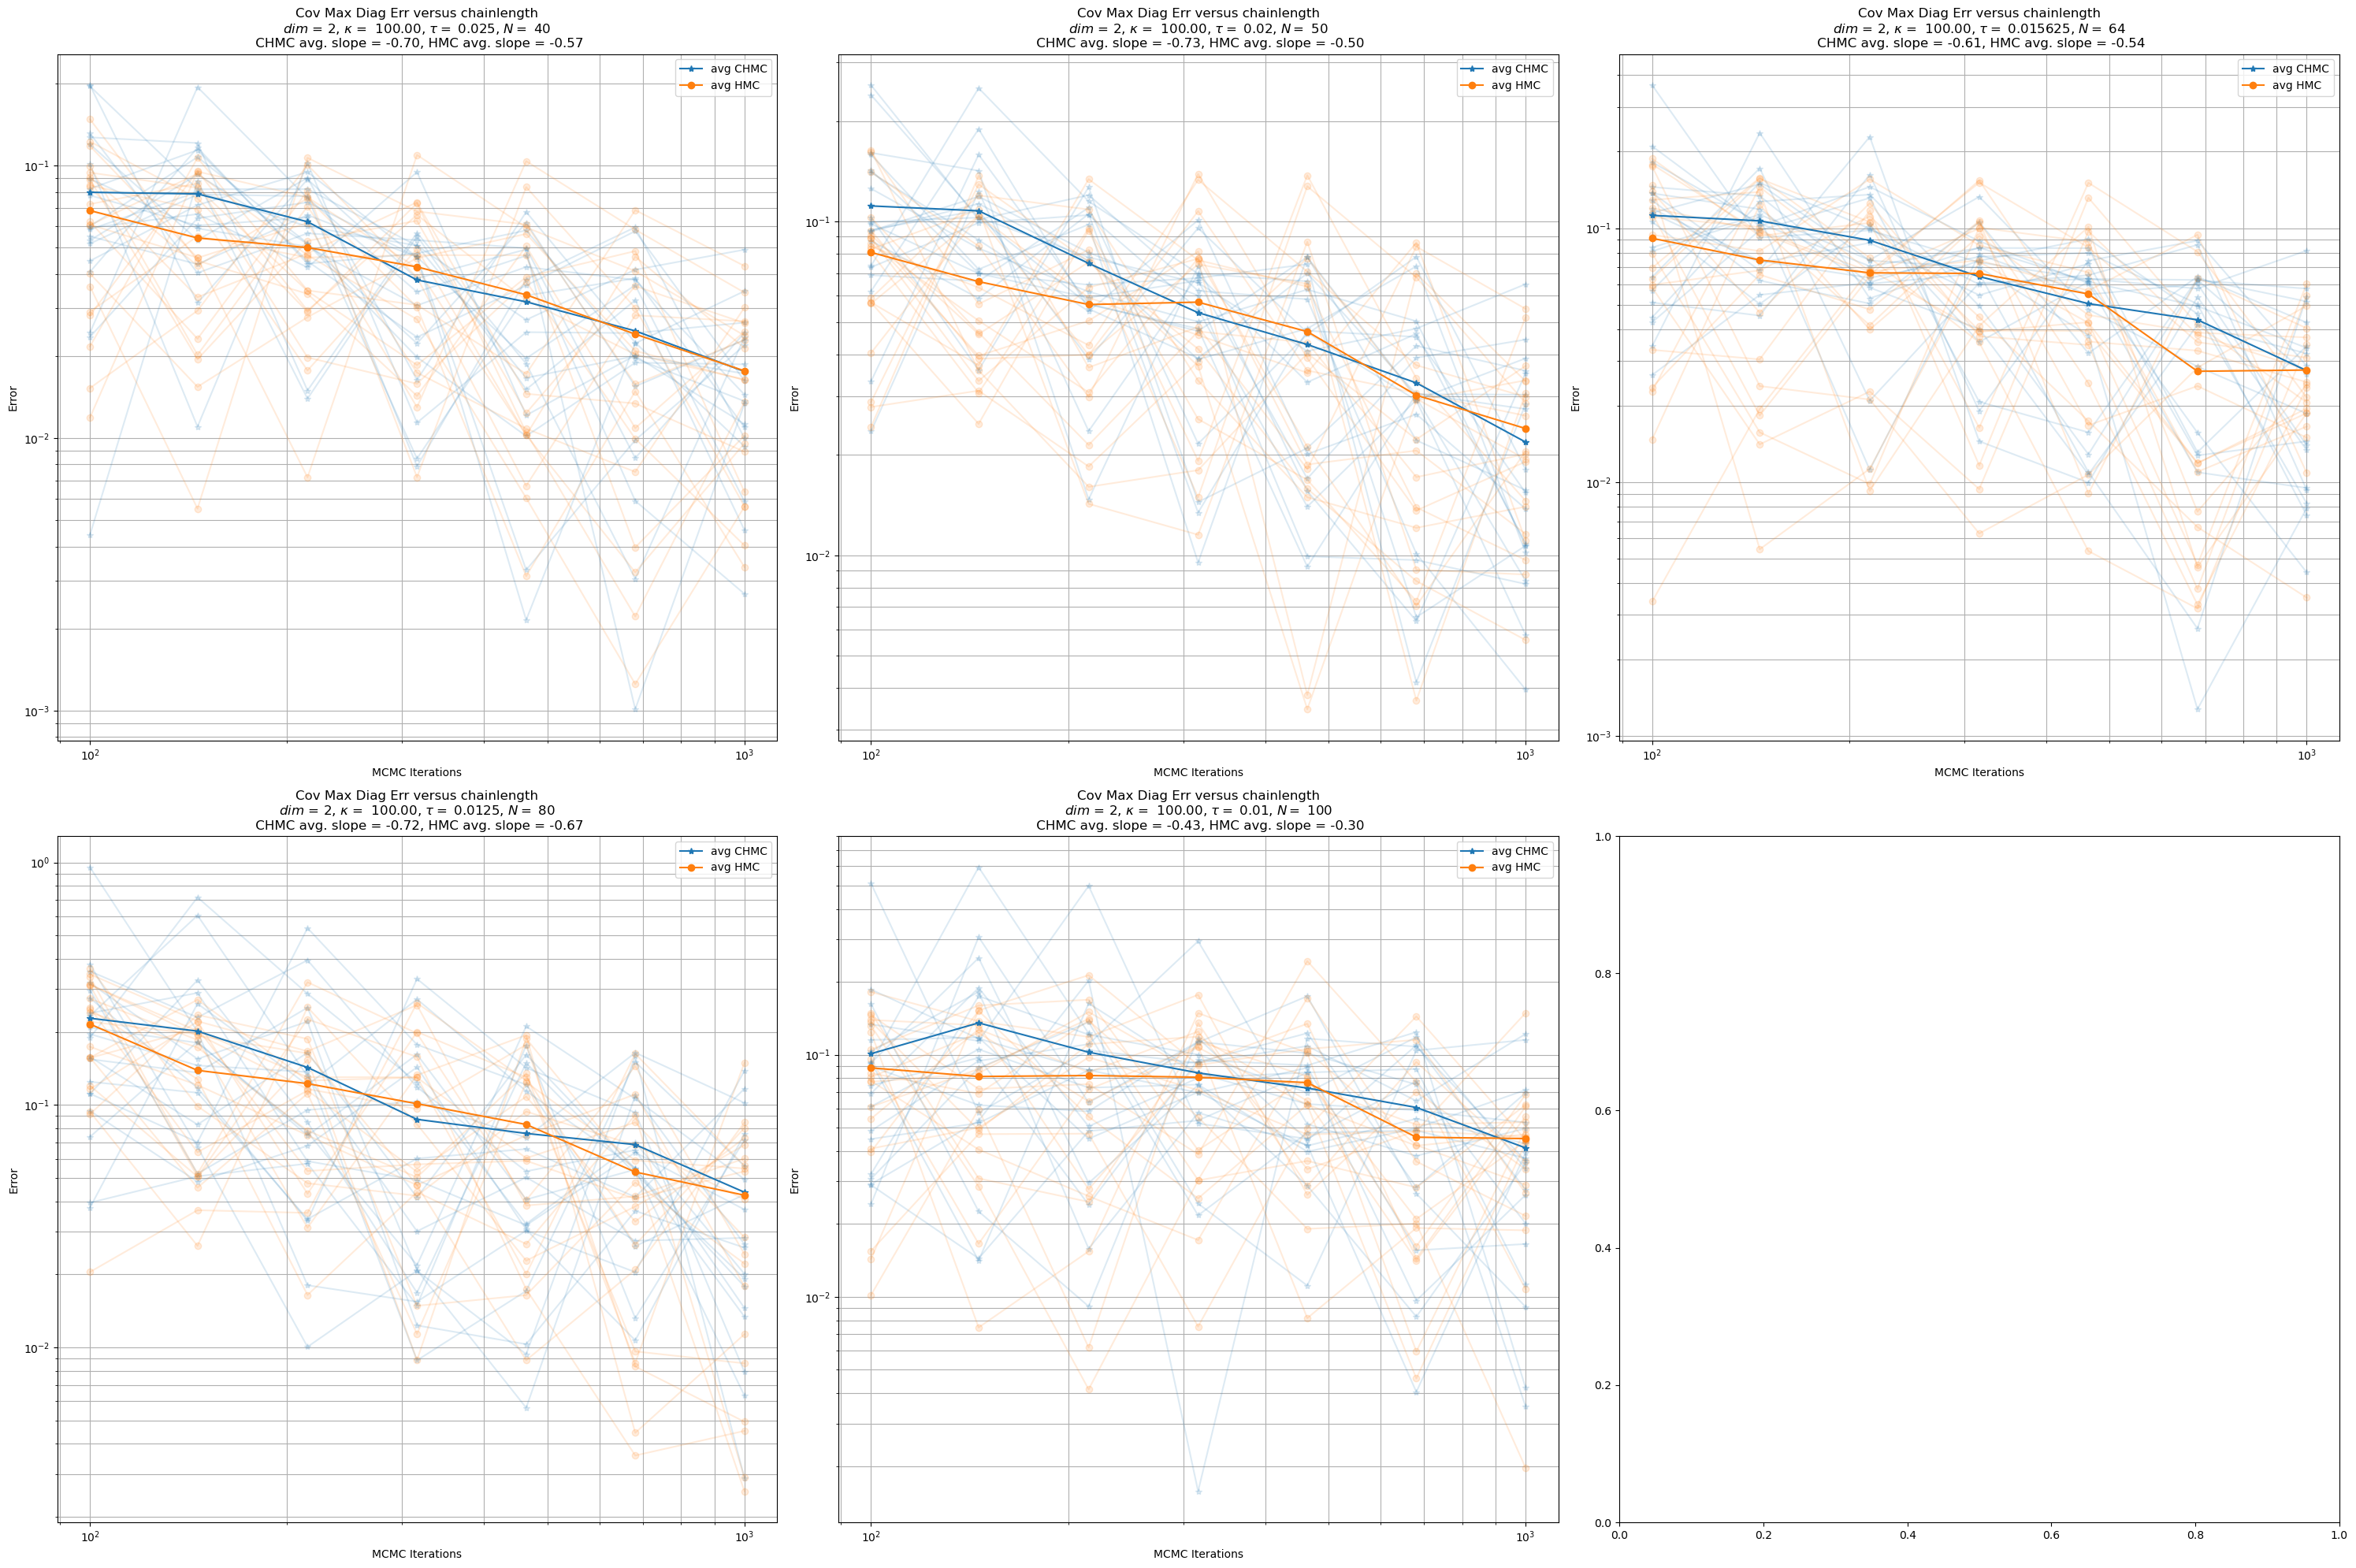

In [144]:
fig, axes = plt.subplots(2, 3, figsize=(30, 20))
axes = axes.flatten()

for i,val in enumerate(τs):
# only doing one dim right now 
    T = 1.0
    N = int(jnp.ceil(T / val))
    tol = 1e-2
    max_iter = 2
    config = IntegratorConfig(τ=val,
                            T=T,
                            N=N,
                            tol=tol,
                            max_iter = max_iter)
    plt.sca(axes[i])
    gen_τ_plots(lens, chmc_cov_metric, hmc_cov_metric, config, i, dims=dims, cond = conds[-3], slope=True)

plt.tight_layout()
plt.show()

In [208]:
from scipy.stats import ecdf
testcdf = ecdf(hmc_chain[1])

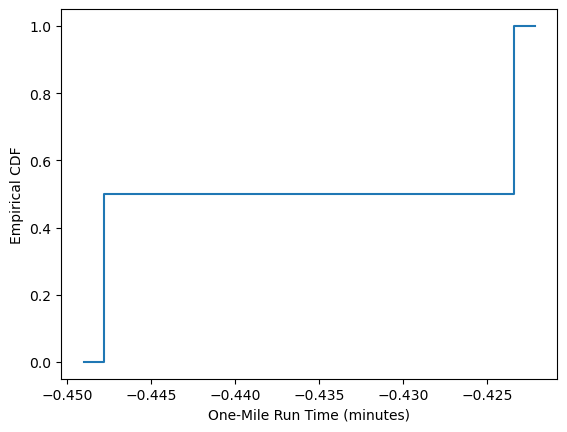

In [212]:
ax = plt.subplot()
testcdf.cdf.plot(ax)
ax.set_xlabel('One-Mile Run Time (minutes)')
ax.set_ylabel('Empirical CDF')
plt.show()

In [ ]:
from scipy.stats import wasserstein_distance_nd as w1_dist_nd
from scipy.stats import ecdf
numpoints = 201
minval = -1
maxval = 1
x = np.linspace( minval, maxval, numpoints)
y = np.linspace( minval, maxval, numpoints)
X, Y = np.meshgrid(x,y)
XY = np.stack([X,Y], axis=-1)

AXY = XY @ κ100_mat.T
Z   = np.einsum('...i,...i->...', XY, AXY)
pdf = np.exp(-0.5 * Z)          
pdf /= pdf.sum()   

testcdf = ecdf(hmc_chain[1])

w1 = w1_dist_nd(
    hmc_chainring[1],   # (96, 2)  — uniform weights (1/96 each)
    XY,           # (N*N, 2) — reference distribution points
    v_weights=pdf
)
print(f"Wasserstein-1 (2D): {w1:.6f}")

ValueError: Invalid input values. The inputs must have either one or two dimensions.

In [214]:
XY.shape

(201, 201, 2)

In [232]:
import numpy as np
from scipy.stats import wasserstein_distance_nd

# ── 1. Build grid and evaluate PDF ──────────────────────────────────────────
N = 201
x = np.linspace(-3, 3, N)
y = np.linspace(-3, 3, N)
Gx, Gy = np.meshgrid(x, y)
grid = np.stack([Gx, Gy], axis=-1).reshape(-1, 2)  # (N*N, 2)

AXY_grid = grid @ np.array(κ100_mat).T              # (N*N, 2)
Z_grid   = np.einsum('...i,...i->...', grid, AXY_grid)  # (N*N,)
pdf_grid = np.exp(-0.5 * Z_grid)                    # (N*N,)
pdf_grid /= pdf_grid.sum()                          # normalise to weights
M = 200
idx = np.random.choice(len(grid), size=M, p=pdf_grid)
pdf_samples = grid[idx]     
# ── 2. Wasserstein-1 ─────────────────────────────────────────────────────────
w1 = wasserstein_distance_nd(
    hmc_chainring[1],   # (96, 2)  — your sample, uniform weights
    pdf_samples
)
print(f"Wasserstein-1: {w1:.6f}")

Wasserstein-1: 0.268334


In [258]:
count = 20
M = 200
random_w1_distances = np.zeros(count)
for i in range(count):
        idx = np.random.choice(len(grid), size=M, p=pdf_grid)
        pdf_samples = grid[idx]   
        random_w1_distances[i] = w1 = wasserstein_distance_nd(
                    hmc_chainring[1],   # (96, 2)  — your sample, uniform weights
                    pdf_samples)


min:  0.2041, 
max:  0.4997, 
avg:  0.3377,
std:  0.0505


(array([ 1.,  5., 11., 20., 29., 18.,  7.,  7.,  1.,  1.]),
 array([0.20405115, 0.2336121 , 0.26317305, 0.292734  , 0.32229496,
        0.35185591, 0.38141686, 0.41097781, 0.44053876, 0.47009971,
        0.49966066]),
 <BarContainer object of 10 artists>)

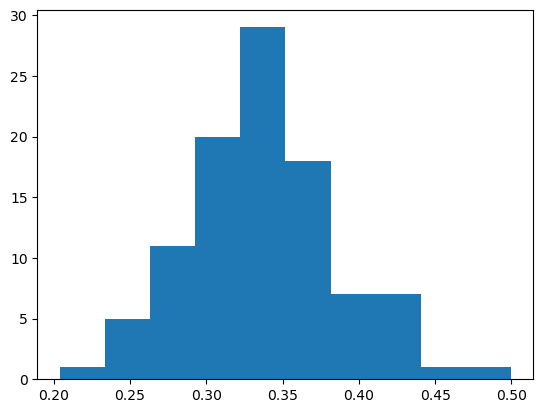

In [239]:
plt.hist(random_w1_distances)

In [ ]:
# ========================================
# τCHMC Chain Ring: Wasserstein Analysis
# ring.shape: (numτs, len, run )

# Need to compare chain accepted num samples to similar PDF num samples

# ========================================

from scipy.stats import wasserstein_distance_nd

# ── 1. Build grid and evaluate PDF ──────────────────────────────────────────
N = 201
x = np.linspace(-3, 3, N)
y = np.linspace(-3, 3, N)
Gx, Gy = np.meshgrid(x, y)
grid = np.stack([Gx, Gy], axis=-1).reshape(-1, 2)  # (NxN, 2)

AXY_grid = grid @ np.array(κ100_mat).T              # (NxN, 2)
Z_grid   = np.einsum('...i,...i->...', grid, AXY_grid)  
pdf_grid = np.exp(-0.5 * Z_grid)                    
pdf_grid /= pdf_grid.sum()                          

# random subset of points from grid. could actually just do uniformly chose points but whatever for now
M = 100
idx = np.random.choice(len(grid), size=M, p=pdf_grid)
pdf_samples = grid[idx]     

w1 = wasserstein_distance_nd(
    hmc_chainring[1],  
    pdf_samples # might be incorrect comparison here
)





(96, 2)

In [262]:
len(chmc_chainring)

700

In [ ]:
import metrics
# This takes like 35 min to run
# τCHMC Chain Ring: Wasserstein Analysis
# ring.shape: (numτs, len, run )


# CHMC
chmc_w1_dist = []
for i,chain in enumerate(chmc_chainring):
    idx = np.random.choice(len(grid), size=M, p=pdf_grid)
    chmc_w1_dist.append(wasserstein_distance_nd(chmc_chainring[i],pdf_samples))
chmc_w1_dist = jnp.array(chmc_w1_dist).reshape(numτs,mcmc_iter_count,runs)

TypeError: cannot reshape array of shape (700,) (size 700) into shape (5, 7, 20, 2, 2) (size 2800)

In [ ]:
# This takes like 39 min to run
# HMC
hmc_w1_dist = []
for i,chain in enumerate(hmc_chainring):
    idx = np.random.choice(len(grid), size=M, p=pdf_grid)
    hmc_w1_dist.append(wasserstein_distance_nd(hmc_chainring[i],pdf_samples))
hmc_w1_dist = jnp.array(hmc_w1_dist).reshape(numτs,mcmc_iter_count,runs)

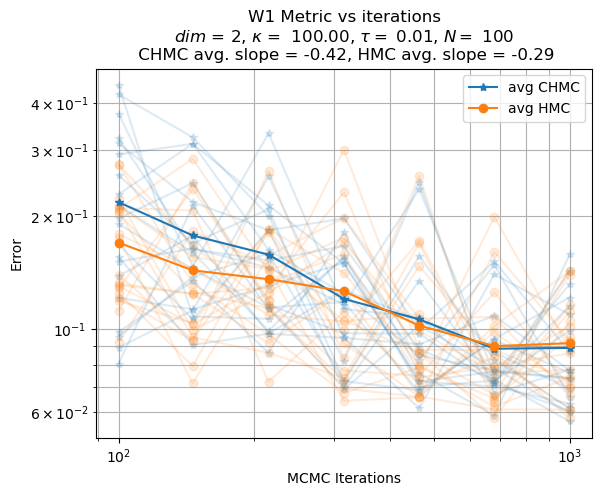

In [ ]:
def gen_τ_plots(lens, 
              chmc_metrics, 
              hmc_metrics, 
              config, 
              i, 
              dims = dims,
              cond = conds,
              slope=False, 
              avg=True,
              title = 'Cov Max Diag Err versus MCMC Iterations'):
    plt.loglog(lens, chmc_metrics[i,:], '-*', color = 'C0', alpha = 0.15)
    plt.loglog(lens, hmc_metrics[i,:], '-o', color = 'C1', alpha = 0.15)
    title = title
    subtitle1 = f'\n$dim$ = {dims[0]}, $\kappa$ = {cond: 0.2f}, $\\tau = $ {config.τ}, $N = $ {config.N}'
    if avg:
        avg_chmc = np.mean(chmc_metrics[i,:], axis = 1)
        plt.loglog(lens, avg_chmc, '-*', color = 'C0', label ='avg CHMC', alpha = 1)
        avg_hmc = np.mean(hmc_metrics[i,:], axis = 1)
        plt.loglog(lens, avg_hmc , '-o', color = 'C1', label ='avg HMC', alpha = 1)
    if slope:
        chmc_p = np.polyfit(np.log(lens), np.log(avg_chmc), 1)
        hmc_p = np.polyfit(np.log(lens), np.log(avg_hmc), 1)

        # slop of avg chain subtitle
        subtitle2 = f'\n CHMC avg. slope = {chmc_p[0]:.2f}, HMC avg. slope = {hmc_p[0]:.2f}'

        # combined subtitle
        plt.title(title+subtitle1+subtitle2)
    else:
        plt.title(title + subtitle1)
    plt.xlabel('MCMC Iterations')
    plt.ylabel('Error')
    plt.grid(which='minor')
    plt.grid(which='major')
    plt.legend()
gen_τ_plots(lens, chmc_w1_dist, hmc_w1_dist, config, 0, dims=dims, cond = conds[-3], slope=True, title = 'W1 Metric vs MCMC Iterations')

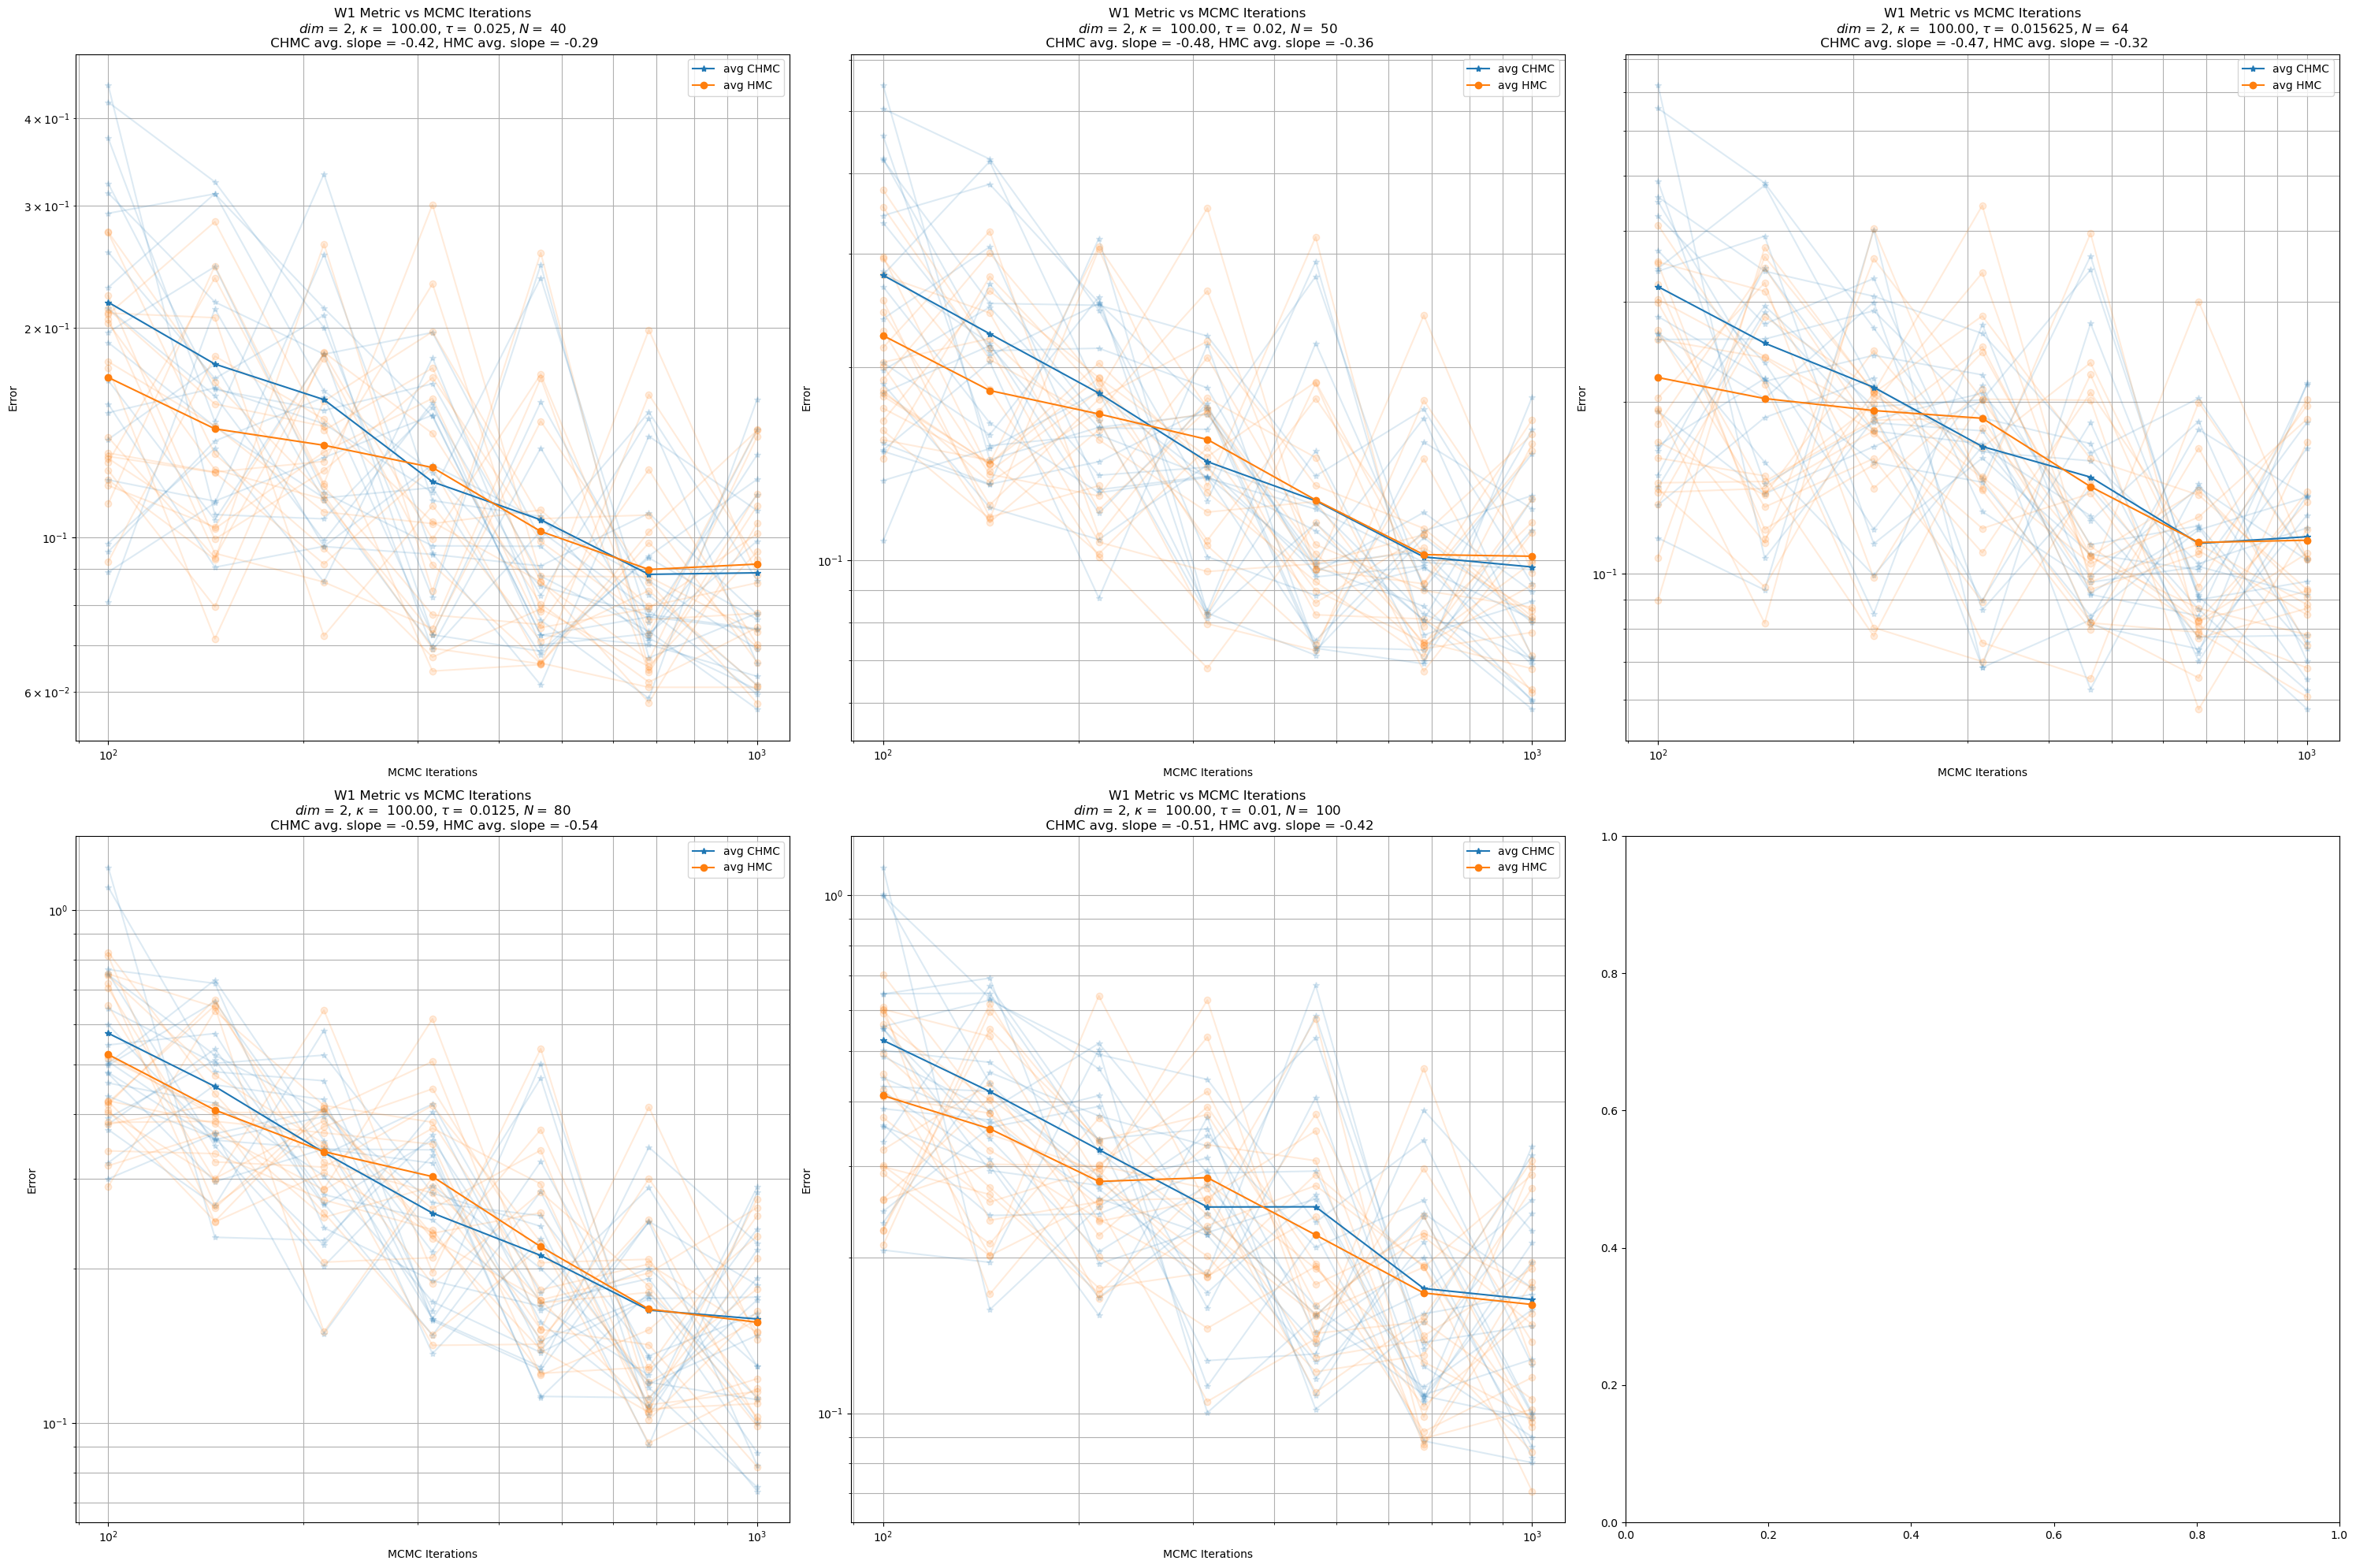

In [269]:
fig, axes = plt.subplots(2, 3, figsize=(30, 20))
axes = axes.flatten()

for i,val in enumerate(τs):
# only doing one dim right now 
    T = 1.0
    N = int(jnp.ceil(T / val))
    tol = 1e-2
    max_iter = 2
    config = IntegratorConfig(τ=val,
                            T=T,
                            N=N,
                            tol=tol,
                            max_iter = max_iter)
    plt.sca(axes[i])
    gen_τ_plots(lens, chmc_w1_dist, hmc_w1_dist, config, i, dims=dims, cond = conds[-3], slope=True, title = 'W1 Metric vs MCMC Iterations')

plt.tight_layout()
plt.show()